# FIFA World Cup 2026 — Full Tournament Prediction & Monte Carlo Simulation

**Author:** Senior Data Scientist / MLOps / Football Analytics / Kaggle Grandmaster pipeline

This notebook predicts the **entire FIFA World Cup 2026** tournament:

* Group stage scores, match winners, corners, yellow & red cards
* Group standings + the best 8 third-placed teams (new 48-team / 12-group format)
* Round of 32 → Round of 16 → Quarter-finals → Semi-finals → Final
* Champion probabilities from **100,000 Monte Carlo simulations**
* Automatic submission file generation

The pipeline is **modular, leakage-safe, reproducible and heavily vectorized**
(the full 100k-tournament Monte Carlo runs in seconds thanks to NumPy).

---
## SECTION 1 — Imports and Configuration

We fix every random seed (Python, NumPy, and all model seeds), configure
warnings/plotting, and centralize hyper-parameters in a single `CFG` class so
the whole notebook can be re-configured from one place.

In [38]:
import os
import random
import warnings
from dataclasses import dataclass, field
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             mean_squared_error)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 60)


@dataclass
class CFG:
    """Central configuration object — every knob of the pipeline lives here."""
    seed: int = 42
    data_dir: str = "Dataset"
    # Monte Carlo (can be overridden via the N_SIMS environment variable)
    n_simulations: int = int(os.environ.get("N_SIMS", 100_000))
    # Time-based split date for model validation (no leakage)
    valid_start: str = "2022-01-01"
    train_start: str = "1993-01-01"      # modern era only for model training
    # Elo → goals calibration
    home_adv_elo: float = 50.0           # Elo bonus when a true host plays at home
    # Ensemble weights (requirement: 40% Poisson / 30% XGB / 20% CatBoost / 10% LGBM)
    w_poisson: float = 0.40
    w_xgb: float = 0.30
    w_cat: float = 0.20
    w_lgb: float = 0.10
    hosts: tuple = ("United States", "Mexico", "Canada")
    output_dir: str = "."


cfg = CFG()

# --- Global reproducibility -------------------------------------------------
random.seed(cfg.seed)
np.random.seed(cfg.seed)
rng = np.random.default_rng(cfg.seed)

print(f"Configuration ready | seed={cfg.seed} | simulations={cfg.n_simulations:,}")

Configuration ready | seed=42 | simulations=100,000


---
## SECTION 2 — Load Datasets

We load every CSV, print its shape/columns, display the head and run basic
integrity checks (duplicates + missing values). When present, the updated
`WorldCupMatches.csv` is loaded directly and used for World-Cup-specific
history features; otherwise the notebook falls back to `results.csv`.

In [39]:
def load_csv(name: str, **kw) -> pd.DataFrame:
    """Load a CSV from the dataset folder with UTF-8 handling."""
    path = os.path.join(cfg.data_dir, name)
    df = pd.read_csv(path, encoding="utf-8-sig", **kw)
    print(f"\n=== {name} ===")
    print(f"shape   : {df.shape}")
    print(f"columns : {list(df.columns)}")
    print(f"duplicated rows : {df.duplicated().sum()}")
    print(f"missing values  : {int(df.isna().sum().sum())}")
    display(df.head(3))
    return df


group_fixtures = load_csv("group_fixtures.csv")
knockout_slots = load_csv("knockout_slots.csv")
historical_elo = load_csv("Historical_eloratings.csv")
current_elo    = load_csv("elo_ratings.csv")
results        = load_csv("results.csv")
world_cup_matches_raw = load_csv("WorldCupMatches.csv")

print(f"\nLoaded updated WorldCupMatches.csv: {world_cup_matches_raw.shape}")


=== group_fixtures.csv ===
shape   : (72, 6)
columns : ['match_id', 'group', 'home_team', 'away_team', 'date_utc', 'venue']
duplicated rows : 0
missing values  : 0


,match_id,group,home_team,away_team,date_utc,venue
0,1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City"
1,2,A,South Korea,UEFA Playoff D,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara"
2,3,B,Canada,UEFA Playoff A,2026-06-12T19:00:00Z,"BMO Field, Toronto"



=== knockout_slots.csv ===
shape   : (32, 7)
columns : ['match_id', 'round', 'multiplier', 'date_utc', 'venue', 'slot_home', 'slot_away']
duplicated rows : 0
missing values  : 0


,match_id,round,multiplier,date_utc,venue,slot_home,slot_away
0,73,Round of 32,1,2026-06-28T19:00:00Z,"SoFi Stadium, Los Angeles",Runner-up Group A,Runner-up Group B
1,74,Round of 32,1,2026-06-29T17:00:00Z,"NRG Stadium, Houston",Winner Group C,Runner-up Group F
2,75,Round of 32,1,2026-06-29T20:30:00Z,"Gillette Stadium, Boston",Winner Group E,Best 3rd (Groups A/B/C/D/F)



=== Historical_eloratings.csv ===
shape   : (6678, 4)
columns : ['date', 'team', 'rating', 'change']
duplicated rows : 0
missing values  : 31


...


=== results.csv ===
shape   : (49477, 9)
columns : ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
duplicated rows : 0
missing values  : 88


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False



=== WorldCupMatches.csv ===
shape   : (4572, 20)
columns : ['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name', 'Home Team Goals', 'Away Team Goals', 'Away Team Name', 'Win conditions', 'Attendance', 'Half-time Home Goals', 'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials']
duplicated rows : 3735
missing values  : 74402


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA



Loaded updated WorldCupMatches.csv: (4572, 20)


---
## SECTION 3 — Data Cleaning

* Standardize team names across every dataset (single canonical vocabulary).
* Convert date columns to `datetime`.
* Remove duplicates & handle missing values.
* Normalize tournament names.
* Map the qualification-playoff placeholders (`UEFA Playoff A..D`,
  `FIFA Playoff 1..2`) to configurable representative teams so the bracket is
  fully populated (edit `PLACEHOLDER_TEAMS` when the real winners are known).

In [40]:
# ---------------------------------------------------------------------------
# 3.1 Canonical team-name mapping helpers
# ---------------------------------------------------------------------------
TEAM_NAME_MAP = {
    # fixtures / knockout naming  ->  canonical (results.csv / elo_ratings.csv)
    "USA": "United States",
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Cabo Verde": "Cape Verde",
    "Curaçao": "Curacao",
    "Czechia": "Czech Republic",
    "Republic of Ireland": "Ireland",
    "US Virgin Islands": "United States Virgin Islands",
    "Türkiye": "Turkey",
}

# Representative teams for the six qualification-playoff placeholder slots.
PLACEHOLDER_TEAMS = {
    "UEFA Playoff A": "Italy",
    "UEFA Playoff B": "Ukraine",
    "UEFA Playoff C": "Turkey",
    "UEFA Playoff D": "Denmark",
    "FIFA Playoff 1": "DR Congo",
    "FIFA Playoff 2": "Bolivia",
}


def standardize_team(name: str) -> str:
    """Map any raw team name to the canonical vocabulary (leak-free lookup)."""
    if pd.isna(name):
        return name
    name = str(name).strip()
    name = PLACEHOLDER_TEAMS.get(name, name)
    return TEAM_NAME_MAP.get(name, name)


def standardize_team_columns(df: pd.DataFrame, cols) -> pd.DataFrame:
    """Apply `standardize_team` to every team column of a dataframe."""
    for c in cols:
        df[c] = df[c].map(standardize_team)
    return df


# ---------------------------------------------------------------------------
# 3.2 Apply cleaning to every dataset
# ---------------------------------------------------------------------------
# -- results.csv ------------------------------------------------------------
results = standardize_team_columns(results, ["home_team", "away_team"])
results["date"] = pd.to_datetime(results["date"])
results["neutral"] = results["neutral"].astype(str).str.upper().eq("TRUE") | results["neutral"].astype(bool)
results = results.drop_duplicates().reset_index(drop=True)
results = results.dropna(subset=["home_score", "away_score"])          # future/unplayed rows
results[["home_score", "away_score"]] = results[["home_score", "away_score"]].astype(int)
# Normalize tournament names (strip whitespace + unify qualification labels)
results["tournament"] = (results["tournament"].str.strip()
                         .str.replace(r"\s+", " ", regex=True))
results["tournament_norm"] = np.select(
    [results["tournament"].eq("FIFA World Cup"),
     results["tournament"].str.contains("World Cup qual", case=False),
     results["tournament"].str.contains("UEFA Euro|Copa Am|African Cup|Africa Cup|AFC Asian Cup|Gold Cup", case=False),
     results["tournament"].str.contains("qual", case=False),
     results["tournament"].eq("Friendly")],
    ["World Cup", "World Cup Qualifier", "Continental", "Continental Qualifier", "Friendly"],
    default="Other",
)

# -- WorldCupMatches.csv ------------------------------------------------------
def clean_world_cup_matches(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize common Kaggle WorldCupMatches schemas into a compact match log."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    rename = {
        "Year": "year", "Datetime": "date", "Date": "date",
        "Home Team Name": "home_team", "Away Team Name": "away_team",
        "Home Team Goals": "home_score", "Away Team Goals": "away_score",
        "Home Team Initials": "home_initials", "Away Team Initials": "away_initials",
        "Stage": "stage", "Round": "stage",
    }
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
    required = ["home_team", "away_team", "home_score", "away_score"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"WorldCupMatches.csv missing required columns: {missing}")
    if "date" not in df.columns:
        df["date"] = pd.to_datetime(df.get("year", 1930).astype(str) + "-01-01", errors="coerce")
    else:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        if "year" in df.columns:
            year_str = pd.to_numeric(df["year"], errors="coerce").astype("Int64").astype(str)
            df["date"] = df["date"].fillna(pd.to_datetime(year_str + "-01-01", errors="coerce"))
    df = standardize_team_columns(df, ["home_team", "away_team"])
    df = df.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
    df[["home_score", "away_score"]] = df[["home_score", "away_score"]].astype(int)
    df["tournament"] = "FIFA World Cup"
    df["tournament_norm"] = "World Cup"
    return df.drop_duplicates().reset_index(drop=True)


world_cup_matches = clean_world_cup_matches(world_cup_matches_raw)
print(f"Cleaned WorldCupMatches.csv: {world_cup_matches.shape}")

# Fold the updated WorldCupMatches.csv into the modeling history so every
# World-Cup pedigree feature reflects the user-provided file.
wc_for_results = world_cup_matches[["date", "home_team", "away_team", "home_score",
                                    "away_score", "tournament", "tournament_norm"]].copy()
wc_for_results["country"] = np.nan
wc_for_results["neutral"] = True
results = pd.concat([
    results[~results["tournament_norm"].eq("World Cup")],
    wc_for_results[results.columns.intersection(wc_for_results.columns).tolist()]
], ignore_index=True, sort=False)
results = results.drop_duplicates(subset=["date", "home_team", "away_team", "home_score", "away_score"], keep="last")
print(f"Modeling history after WorldCupMatches.csv refresh: {results.shape}")

# -- historical Elo -----------------------------------------------------------
historical_elo["team"] = historical_elo["team"].map(standardize_team)
historical_elo["date"] = pd.to_datetime(historical_elo["date"], format="mixed", errors="coerce")
historical_elo = historical_elo.dropna(subset=["date"])                 # unparsable dates
historical_elo = (historical_elo.drop_duplicates(subset=["date", "team"], keep="last")
                  .sort_values(["team", "date"]).reset_index(drop=True))

# -- current Elo --------------------------------------------------------------
current_elo["Team"] = current_elo["Team"].map(standardize_team)
current_elo = current_elo.drop_duplicates(subset=["Team"]).reset_index(drop=True)
ELO_NOW = dict(zip(current_elo["Team"], current_elo["Elo"].astype(float)))

# -- fixtures & knockout slots ------------------------------------------------
group_fixtures = standardize_team_columns(group_fixtures, ["home_team", "away_team"])
group_fixtures["date_utc"] = pd.to_datetime(group_fixtures["date_utc"])
knockout_slots["date_utc"] = pd.to_datetime(knockout_slots["date_utc"])

# ---------------------------------------------------------------------------
# 3.3 Cross-dataset consistency check — every tournament team must be known
# ---------------------------------------------------------------------------
TEAMS_2026 = sorted(set(group_fixtures["home_team"]) | set(group_fixtures["away_team"]))
assert len(TEAMS_2026) == 48, f"Expected 48 teams, got {len(TEAMS_2026)}"

missing_elo = [t for t in TEAMS_2026 if t not in ELO_NOW]
missing_hist = [t for t in TEAMS_2026 if t not in set(results["home_team"]) | set(results["away_team"])]
print("Teams missing in current Elo :", missing_elo or "none")
print("Teams missing in results.csv :", missing_hist or "none")
# Fallback: any unranked team receives a conservative default rating
DEFAULT_ELO = 1500.0
for t in missing_elo:
    ELO_NOW[t] = DEFAULT_ELO

print(f"\nAll 48 tournament teams reconciled. Example Elo: Argentina={ELO_NOW['Argentina']:.0f}")

Cleaned WorldCupMatches.csv: (836, 22)
Modeling history after WorldCupMatches.csv refresh: (49276, 10)
Teams missing in current Elo : none
Teams missing in results.csv : none

All 48 tournament teams reconciled. Example Elo: Argentina=2144


---
## SECTION 4 — Feature Engineering (leakage-safe)

Every rolling feature is computed **only from matches strictly before** the
current match (`groupby(...).shift(1)` before any rolling window), so there
is no target leakage. We build a *long* team-level match log (one row per
team per match) to compute form features, then merge them back to the
match-level table for both teams.

In [41]:
class FeatureEngineer:
    """Builds a leakage-safe feature matrix from the raw match history."""

    ROLL_COLS = [
        "home_elo", "away_elo", "elo_diff", "elo_sum",
        "home_rolling_elo_change_last5", "away_rolling_elo_change_last5",
        "home_goals_last5", "away_goals_last5",
        "home_conceded_last5", "away_conceded_last5",
        "home_points_last5", "away_points_last5",
        "home_winrate_last10", "away_winrate_last10",
        "home_goal_difference_last5", "away_goal_difference_last5",
        "attack_strength_home", "attack_strength_away",
        "defense_strength_home", "defense_strength_away",
        "home_days_since_last_match", "away_days_since_last_match",
        "neutral", "host_advantage",
        "home_world_cup_history", "away_world_cup_history",
        "home_world_cup_win_rate", "away_world_cup_win_rate",
        "home_knockout_experience", "away_knockout_experience",
        "tournament_weight",
    ]

    def __init__(self, results: pd.DataFrame, historical_elo: pd.DataFrame):
        self.results = results.sort_values("date").reset_index(drop=True)
        self.hist_elo = historical_elo

    # -- Elo as-of merge ------------------------------------------------------
    def _merge_elo(self, df: pd.DataFrame) -> pd.DataFrame:
        """Attach the latest Elo rating *before* each match (as-of join)."""
        elo = self.hist_elo.sort_values("date")
        for side in ("home", "away"):
            df = pd.merge_asof(
                df.sort_values("date"),
                elo.rename(columns={"team": f"{side}_team", "rating": f"{side}_elo",
                                    "change": f"{side}_elo_change"}),
                on="date", by=f"{side}_team", direction="backward",
                allow_exact_matches=False,   # strictly before match date => no leakage
            )
        df["home_elo"] = df["home_elo"].fillna(DEFAULT_ELO)
        df["away_elo"] = df["away_elo"].fillna(DEFAULT_ELO)
        df["elo_diff"] = df["home_elo"] - df["away_elo"]
        df["elo_sum"] = df["home_elo"] + df["away_elo"]
        return df

    # -- team-level rolling form ------------------------------------------------
    def _team_long_form(self, df: pd.DataFrame) -> pd.DataFrame:
        """One row per (team, match) with goals for/against and points."""
        base = df.reset_index().rename(columns={"index": "match_idx"})
        home = base[["match_idx", "date", "home_team", "home_score", "away_score",
                     "tournament_norm", "home_elo_change"]].copy()
        home.columns = ["match_idx", "date", "team", "gf", "ga", "tournament_norm", "elo_change"]
        away = base[["match_idx", "date", "away_team", "away_score", "home_score",
                     "tournament_norm", "away_elo_change"]].copy()
        away.columns = ["match_idx", "date", "team", "gf", "ga", "tournament_norm", "elo_change"]
        long = pd.concat([home, away], ignore_index=True).sort_values(["team", "date", "match_idx"])
        long["points"] = np.select([long.gf > long.ga, long.gf == long.ga], [3, 1], 0)
        long["win"] = (long.gf > long.ga).astype(int)
        long["gd"] = long.gf - long.ga
        long["is_wc"] = long["tournament_norm"].eq("World Cup").astype(int)
        long["wc_win"] = long["is_wc"] * long["win"]
        long["is_knockout"] = long["is_wc"]  # WC matches proxy knockout/high-stakes exposure

        g = long.groupby("team", sort=False)
        # shift(1) BEFORE rolling => only past matches are used (leakage-safe)
        for col, roll_name, window, agg in [
            ("gf", "goals_last5", 5, "mean"),
            ("ga", "conceded_last5", 5, "mean"),
            ("points", "points_last5", 5, "mean"),
            ("gd", "goal_difference_last5", 5, "mean"),
            ("win", "winrate_last10", 10, "mean"),
            ("elo_change", "rolling_elo_change_last5", 5, "sum"),
        ]:
            long[roll_name] = (g[col].apply(lambda s: s.shift(1).rolling(window, min_periods=1)
                                            .agg(agg)).reset_index(level=0, drop=True))
        # cumulative World-Cup pedigree (past only)
        long["world_cup_history"] = g["is_wc"].apply(lambda s: s.shift(1).cumsum()).reset_index(level=0, drop=True)
        long["wc_wins_cum"] = g["wc_win"].apply(lambda s: s.shift(1).cumsum()).reset_index(level=0, drop=True)
        long["world_cup_win_rate"] = (long["wc_wins_cum"] / long["world_cup_history"].replace(0, np.nan)).fillna(0)
        long["knockout_experience"] = long["world_cup_history"]
        long["days_since_last_match"] = g["date"].diff().dt.days
        # attack/defense strength = long-run expanding goal averages (past only)
        long["attack_strength"] = g["gf"].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)
        long["defense_strength"] = g["ga"].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)
        return long

    def build(self) -> pd.DataFrame:
        df = self._merge_elo(self.results.copy())
        long = self._team_long_form(df)

        feat_cols = ["goals_last5", "conceded_last5", "points_last5",
                     "goal_difference_last5", "winrate_last10",
                     "rolling_elo_change_last5", "world_cup_history",
                     "world_cup_win_rate", "knockout_experience",
                     "days_since_last_match", "attack_strength", "defense_strength"]

        for side in ("home", "away"):
            side_df = long.merge(
                df.reset_index().rename(columns={"index": "match_idx"})[["match_idx", f"{side}_team"]],
                left_on=["match_idx", "team"], right_on=["match_idx", f"{side}_team"], how="inner",
            )[["match_idx"] + feat_cols].set_index("match_idx")
            rename = {c: f"{side}_{c}" for c in feat_cols}
            rename.update({"attack_strength": f"attack_strength_{side}",
                           "defense_strength": f"defense_strength_{side}"})
            df = df.join(side_df.rename(columns=rename))

        # match-level context features ------------------------------------------------
        df["neutral"] = df["neutral"].astype(int)
        df["host_advantage"] = ((~df["neutral"].astype(bool)) & (df["home_team"] == df["country"].map(standardize_team))).astype(int)
        df["tournament_weight"] = df["tournament_norm"].map(
            {"World Cup": 4.0, "Continental": 3.0, "World Cup Qualifier": 2.5,
             "Continental Qualifier": 2.0, "Other": 1.5, "Friendly": 1.0}).fillna(1.0)
        # exponential time-decay sample weight (half-life ≈ 8 years)
        age_years = (df["date"].max() - df["date"]).dt.days / 365.25
        df["time_decay_weight"] = 0.5 ** (age_years / 8.0)

        # missing-value policy: early-career teams get neutral defaults
        fill_zero = [c for c in df.columns if any(k in c for k in
                     ["last5", "last10", "world_cup", "knockout", "elo_change"])]
        df[fill_zero] = df[fill_zero].fillna(0)
        for side in ("home", "away"):
            df[f"attack_strength_{side}"] = df[f"attack_strength_{side}"].fillna(1.3)
            df[f"defense_strength_{side}"] = df[f"defense_strength_{side}"].fillna(1.3)
            df[f"{side}_days_since_last_match"] = df[f"{side}_days_since_last_match"].clip(upper=365).fillna(30)
        return df


fe = FeatureEngineer(results, historical_elo)
matches = fe.build()
matches = matches[matches["date"] >= cfg.train_start].reset_index(drop=True)

FEATURES = FeatureEngineer.ROLL_COLS
print(f"Feature matrix: {matches.shape}, features used: {len(FEATURES)}")
display(matches[FEATURES].describe().T.head(15))

Feature matrix: (30568, 43), features used: 31


,count,mean,std,min,25%,50%,75%,max
home_elo,30568.0,1525.851675,252.161416,0.000000,1406.00,1500.0,1687.0,2171.000000
away_elo,30568.0,1510.677768,254.869636,0.000000,1392.75,1500.0,1665.0,2171.000000
elo_diff,30568.0,15.173907,271.685279,-1452.000000,-149.00,0.0,182.0,1389.000000
elo_sum,30568.0,3036.529443,428.106215,1103.000000,2784.00,3008.0,3313.0,4249.000000
home_rolling_elo_change_last5,30568.0,1.117116,60.298769,-255.000000,-25.00,0.0,30.0,295.000000
away_rolling_elo_change_last5,30568.0,1.677310,61.122510,-295.000000,-25.00,0.0,30.0,295.000000
home_goals_last5,30568.0,1.404090,0.853234,0.000000,0.80,1.2,1.8,13.600000
away_goals_last5,30568.0,1.359901,0.830795,0.000000,0.80,1.2,1.8,21.000000
home_conceded_last5,30568.0,1.358783,0.950322,0.000000,0.80,1.2,1.8,20.333333
away_conceded_last5,30568.0,1.413147,1.014420,0.000000,0.80,1.2,1.8,19.500000


---
## SECTION 5 — Exploratory Data Analysis

Quick sanity-check of the data: goal distributions (Poisson-like), feature
correlations against the targets, and current team strengths.

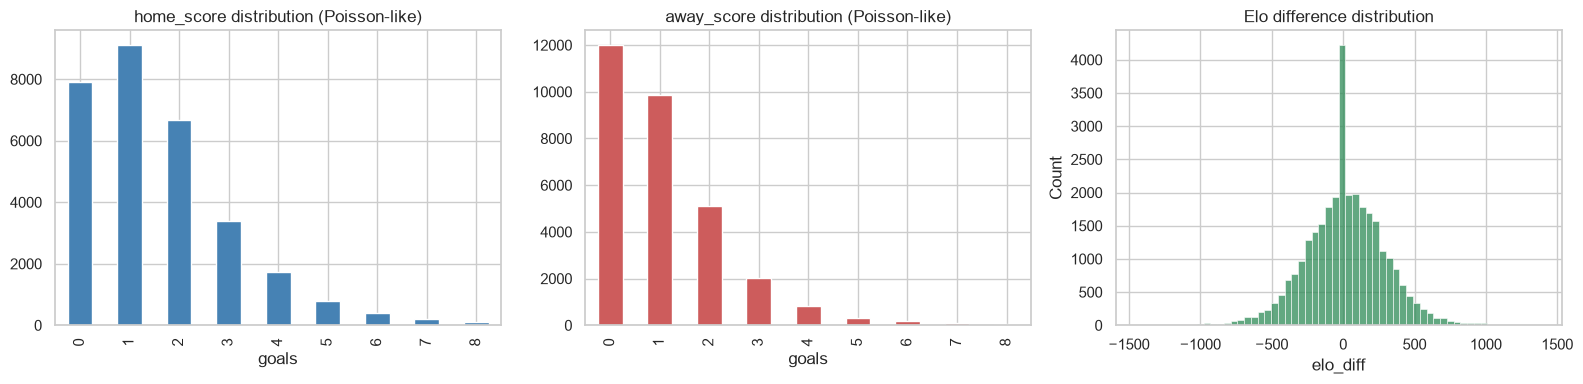

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Goals distributions
for col, ax, color in [("home_score", axes[0], "steelblue"), ("away_score", axes[1], "indianred")]:
    matches[col].value_counts().sort_index().loc[:8].plot(kind="bar", ax=ax, color=color)
    ax.set_title(f"{col} distribution (Poisson-like)")
    ax.set_xlabel("goals")
# Elo difference vs result
sns.histplot(matches["elo_diff"], bins=60, ax=axes[2], color="seagreen")
axes[2].set_title("Elo difference distribution")
plt.tight_layout(); plt.show()

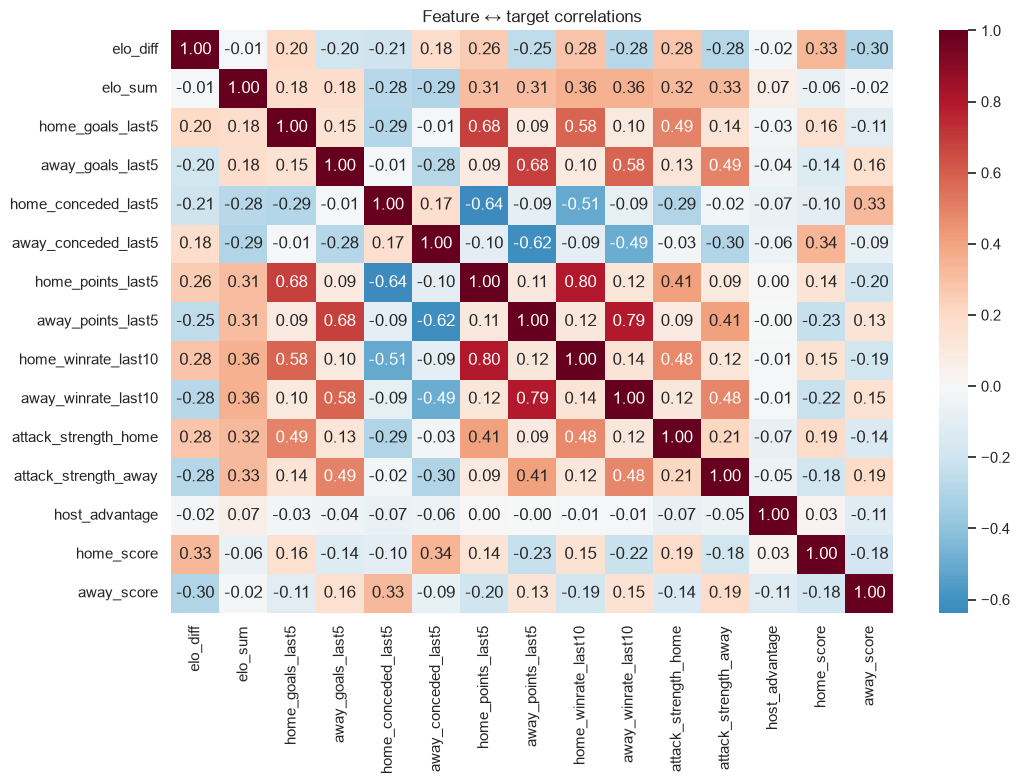

In [43]:
# Correlation of the key numeric features with the goal targets
corr_cols = ["elo_diff", "elo_sum", "home_goals_last5", "away_goals_last5",
             "home_conceded_last5", "away_conceded_last5", "home_points_last5",
             "away_points_last5", "home_winrate_last10", "away_winrate_last10",
             "attack_strength_home", "attack_strength_away", "host_advantage",
             "home_score", "away_score"]
plt.figure(figsize=(11, 8))
sns.heatmap(matches[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Feature ↔ target correlations")
plt.tight_layout(); plt.show()

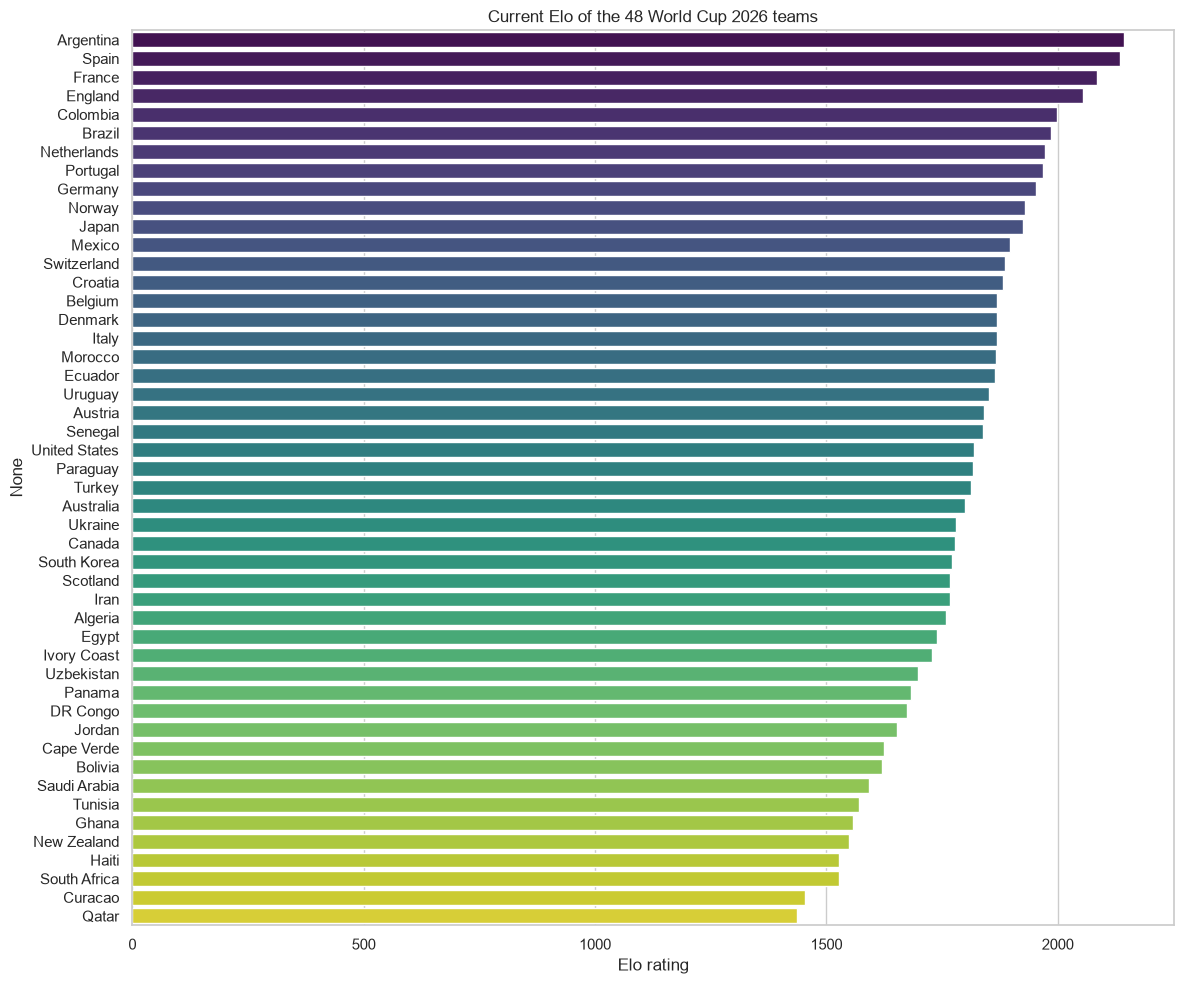

In [44]:
# Current strength of the 48 qualified teams
strength = (pd.Series({t: ELO_NOW[t] for t in TEAMS_2026}, name="Elo")
            .sort_values(ascending=False))
plt.figure(figsize=(12, 10))
sns.barplot(x=strength.values, y=strength.index, palette="viridis")
plt.title("Current Elo of the 48 World Cup 2026 teams")
plt.xlabel("Elo rating"); plt.tight_layout(); plt.show()

---
## SECTION 6 — Target Variables

Primary regression targets are `home_score` / `away_score`; we also derive the
categorical outcome flags `home_win` / `draw` / `away_win` for evaluation.

In [45]:
matches["home_win"] = (matches["home_score"] > matches["away_score"]).astype(int)
matches["draw"] = (matches["home_score"] == matches["away_score"]).astype(int)
matches["away_win"] = (matches["home_score"] < matches["away_score"]).astype(int)

print(matches[["home_win", "draw", "away_win"]].mean().rename("share"))
print(f"\nAvg goals: home={matches.home_score.mean():.2f}, away={matches.away_score.mean():.2f}")

home_win    0.485737
draw        0.233218
away_win    0.281046
Name: share, dtype: float64

Avg goals: home=1.66, away=1.11


---
## SECTION 7 — Train Models (time-based split, no leakage)

We train **five model families**, each with a separate regressor for home and
away goals: `PoissonRegressor`, `LightGBM`, `CatBoost`, `XGBoost` and
`RandomForest`. Validation is strictly time-based (`train < 2022-01-01 ≤ valid`).
Metrics: **MAE, RMSE and Poisson negative log-likelihood** (the natural
scoring rule for count targets). Sample weights = tournament importance ×
exponential time decay.

In [46]:
train_df = matches[matches["date"] < cfg.valid_start]
valid_df = matches[matches["date"] >= cfg.valid_start]
print(f"train: {train_df.shape[0]:,} matches | valid: {valid_df.shape[0]:,} matches")

X_tr, X_va = train_df[FEATURES], valid_df[FEATURES]
w_tr = (train_df["tournament_weight"] * train_df["time_decay_weight"]).values


def poisson_nll(y_true, mu, eps=1e-9):
    """Mean Poisson negative log-likelihood (lower is better)."""
    mu = np.clip(mu, eps, None)
    from scipy.special import gammaln
    return float(np.mean(mu - y_true * np.log(mu) + gammaln(y_true + 1)))


def result_labels(home_goals, away_goals) -> np.ndarray:
    """Convert home/away goals into 3-class match outcome labels."""
    home_goals = np.asarray(home_goals)
    away_goals = np.asarray(away_goals)
    return np.select([home_goals > away_goals, home_goals == away_goals],
                     ["Home Win", "Draw"], default="Away Win")


class GoalModel:
    """Wraps a (home, away) pair of regressors behind one interface."""

    def __init__(self, name, factory):
        self.name = name
        self.m_home, self.m_away = factory(), factory()

    @staticmethod
    def _fit_kwargs(model, w):
        """Route sample weights correctly, including through sklearn Pipelines."""
        if w is None:
            return {}
        if hasattr(model, "steps"):                       # sklearn Pipeline
            return {f"{model.steps[-1][0]}__sample_weight": w}
        return {"sample_weight": w}

    def fit(self, X, yh, ya, w=None):
        self.m_home.fit(X, yh, **self._fit_kwargs(self.m_home, w))
        self.m_away.fit(X, ya, **self._fit_kwargs(self.m_away, w))
        return self

    def predict(self, X):
        mh = np.clip(self.m_home.predict(X), 0.05, 6.0)
        ma = np.clip(self.m_away.predict(X), 0.05, 6.0)
        return mh, ma


MODEL_FACTORIES = {
    "Poisson":      lambda: make_pipeline(StandardScaler(), PoissonRegressor(alpha=1.0, max_iter=500)),
    "LightGBM":     lambda: lgb.LGBMRegressor(objective="poisson", n_estimators=600, learning_rate=0.03,
                                              num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                              random_state=cfg.seed, verbose=-1),
    "CatBoost":     lambda: CatBoostRegressor(loss_function="Poisson", iterations=600, learning_rate=0.05,
                                              depth=6, random_seed=cfg.seed, verbose=0),
    "XGBoost":      lambda: xgb.XGBRegressor(objective="count:poisson", n_estimators=600, learning_rate=0.03,
                                             max_depth=5, subsample=0.8, colsample_bytree=0.8,
                                             random_state=cfg.seed, verbosity=0),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=20,
                                                  random_state=cfg.seed, n_jobs=-1),
}

models, rows = {}, []
for name, factory in MODEL_FACTORIES.items():
    gm = GoalModel(name, factory).fit(X_tr, train_df["home_score"], train_df["away_score"], w_tr)
    mh, ma = gm.predict(X_va)
    y = np.concatenate([valid_df["home_score"], valid_df["away_score"]])
    mu = np.concatenate([mh, ma])
    y_true_result = result_labels(valid_df["home_score"], valid_df["away_score"])
    y_pred_result = result_labels(np.rint(mh), np.rint(ma))
    rows.append({"model": name,
                 "MAE": mean_absolute_error(y, mu),
                 "RMSE": float(np.sqrt(mean_squared_error(y, mu))),
                 "PoissonNLL": poisson_nll(y, mu),
                 "Accuracy": accuracy_score(y_true_result, y_pred_result),
                 "F1_macro": f1_score(y_true_result, y_pred_result, average="macro"),
                 "F1_weighted": f1_score(y_true_result, y_pred_result, average="weighted")})
    models[name] = gm

leaderboard = pd.DataFrame(rows).sort_values("PoissonNLL").reset_index(drop=True)
display(leaderboard)
best_model_name = leaderboard.iloc[0]["model"]
print(f"Best single model by Poisson NLL: {best_model_name}")

train: 26,065 matches | valid: 4,503 matches


,model,MAE,RMSE,PoissonNLL,Accuracy,F1_macro,F1_weighted
0,XGBoost,0.932249,1.239607,1.426585,0.543416,0.512519,0.554979
1,LightGBM,0.933589,1.242820,1.429388,0.542083,0.509113,0.552374
2,CatBoost,0.935862,1.246415,1.429409,0.545858,0.516070,0.557154
3,RandomForest,0.943976,1.254062,1.437183,0.539418,0.507542,0.550143
4,Poisson,0.954946,1.266264,1.451456,0.537864,0.494185,0.540307


Best single model by Poisson NLL: XGBoost


### Model ensemble

Per the specification the production predictor is a fixed-weight blend:
**40% Poisson + 30% XGBoost + 20% CatBoost + 10% LightGBM**.

In [47]:
ENSEMBLE_WEIGHTS = {"Poisson": cfg.w_poisson, "XGBoost": cfg.w_xgb,
                    "CatBoost": cfg.w_cat, "LightGBM": cfg.w_lgb}


def ensemble_predict(X: pd.DataFrame):
    """Weighted-average expected goals from the 4-model ensemble."""
    mh = np.zeros(len(X)); ma = np.zeros(len(X))
    for name, w in ENSEMBLE_WEIGHTS.items():
        h, a = models[name].predict(X)
        mh += w * h; ma += w * a
    return mh, ma


mh, ma = ensemble_predict(X_va)
y = np.concatenate([valid_df["home_score"], valid_df["away_score"]])
mu = np.concatenate([mh, ma])
y_true_result = result_labels(valid_df["home_score"], valid_df["away_score"])
y_pred_result = result_labels(np.rint(mh), np.rint(ma))
ensemble_metrics = {
    "model": "ENSEMBLE",
    "MAE": mean_absolute_error(y, mu),
    "RMSE": float(np.sqrt(mean_squared_error(y, mu))),
    "PoissonNLL": poisson_nll(y, mu),
    "Accuracy": accuracy_score(y_true_result, y_pred_result),
    "F1_macro": f1_score(y_true_result, y_pred_result, average="macro"),
    "F1_weighted": f1_score(y_true_result, y_pred_result, average="weighted"),
}
print(f"ENSEMBLE  MAE={mean_absolute_error(y, mu):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y, mu)):.4f}  "
      f"PoissonNLL={poisson_nll(y, mu):.4f}  "
      f"Accuracy={ensemble_metrics['Accuracy']:.4f}  "
      f"F1_macro={ensemble_metrics['F1_macro']:.4f}")

model_performance = pd.concat([leaderboard, pd.DataFrame([ensemble_metrics])], ignore_index=True)
display(model_performance.sort_values("PoissonNLL").reset_index(drop=True))

ENSEMBLE  MAE=0.9346  RMSE=1.2396  PoissonNLL=1.4286  Accuracy=0.5470  F1_macro=0.5112


,model,MAE,RMSE,PoissonNLL,Accuracy,F1_macro,F1_weighted
0,XGBoost,0.932249,1.239607,1.426585,0.543416,0.512519,0.554979
1,ENSEMBLE,0.934645,1.239586,1.428555,0.546969,0.511213,0.554965
2,LightGBM,0.933589,1.242820,1.429388,0.542083,0.509113,0.552374
3,CatBoost,0.935862,1.246415,1.429409,0.545858,0.516070,0.557154
4,RandomForest,0.943976,1.254062,1.437183,0.539418,0.507542,0.550143
5,Poisson,0.954946,1.266264,1.451456,0.537864,0.494185,0.540307


### Tournament feature snapshots & pairwise expected-goals matrix

For the 2026 simulation each team gets a **frozen feature snapshot** (its most
recent leakage-safe form features + current Elo). We then run the ensemble
once over **all 48×48 ordered team pairs** to pre-compute the expected-goals
matrix `LAM[h, a]` — after that, the entire Monte Carlo needs only NumPy
lookups (massive speed-up, see Section 20).

In [48]:
TEAM_INDEX = {t: i for i, t in enumerate(TEAMS_2026)}
N_TEAMS = len(TEAMS_2026)

# latest per-team snapshot of every rolling feature (from the full match log)
_long = fe._team_long_form(fe._merge_elo(fe.results.copy()))
snap = (_long.sort_values(["team", "date"]).groupby("team").tail(1)
        .set_index("team"))
SNAP_COLS = ["goals_last5", "conceded_last5", "points_last5",
             "goal_difference_last5", "winrate_last10", "rolling_elo_change_last5",
             "world_cup_history", "world_cup_win_rate", "knockout_experience",
             "attack_strength", "defense_strength"]
SNAP_DEFAULTS = {"attack_strength": 1.3, "defense_strength": 1.3}


def team_snapshot(team: str) -> dict:
    """Frozen pre-tournament feature vector for one team (safe defaults)."""
    if team in snap.index:
        s = snap.loc[team, SNAP_COLS].to_dict()
    else:
        s = {c: 0.0 for c in SNAP_COLS}
    return {c: (SNAP_DEFAULTS.get(c, 0.0) if pd.isna(v) else float(v))
            for c, v in s.items()}


SNAPSHOTS = {t: team_snapshot(t) for t in TEAMS_2026}


def build_feature_row(home: str, away: str) -> dict:
    """Assemble the full model feature vector for one 2026 fixture."""
    hs, aw = SNAPSHOTS[home], SNAPSHOTS[away]
    he, ae = ELO_NOW.get(home, DEFAULT_ELO), ELO_NOW.get(away, DEFAULT_ELO)
    host = int(home in cfg.hosts)                       # hosts get home advantage
    he_eff = he + cfg.home_adv_elo * host
    row = {
        "home_elo": he_eff, "away_elo": ae,
        "elo_diff": he_eff - ae, "elo_sum": he_eff + ae,
        "home_rolling_elo_change_last5": hs["rolling_elo_change_last5"],
        "away_rolling_elo_change_last5": aw["rolling_elo_change_last5"],
        "home_goals_last5": hs["goals_last5"], "away_goals_last5": aw["goals_last5"],
        "home_conceded_last5": hs["conceded_last5"], "away_conceded_last5": aw["conceded_last5"],
        "home_points_last5": hs["points_last5"], "away_points_last5": aw["points_last5"],
        "home_winrate_last10": hs["winrate_last10"], "away_winrate_last10": aw["winrate_last10"],
        "home_goal_difference_last5": hs["goal_difference_last5"],
        "away_goal_difference_last5": aw["goal_difference_last5"],
        "attack_strength_home": hs["attack_strength"], "attack_strength_away": aw["attack_strength"],
        "defense_strength_home": hs["defense_strength"], "defense_strength_away": aw["defense_strength"],
        "home_days_since_last_match": 7.0, "away_days_since_last_match": 7.0,
        "neutral": int(home not in cfg.hosts), "host_advantage": host,
        "home_world_cup_history": hs["world_cup_history"], "away_world_cup_history": aw["world_cup_history"],
        "home_world_cup_win_rate": hs["world_cup_win_rate"], "away_world_cup_win_rate": aw["world_cup_win_rate"],
        "home_knockout_experience": hs["knockout_experience"], "away_knockout_experience": aw["knockout_experience"],
        "tournament_weight": 4.0,                       # World Cup importance
    }
    return row


# Pre-compute expected goals for EVERY ordered pair of the 48 teams (2 256 rows)
pair_rows, pair_idx = [], []
for h in TEAMS_2026:
    for a in TEAMS_2026:
        if h == a:
            continue
        pair_rows.append(build_feature_row(h, a))
        pair_idx.append((TEAM_INDEX[h], TEAM_INDEX[a]))
pair_X = pd.DataFrame(pair_rows)[FEATURES]
mu_h, mu_a = ensemble_predict(pair_X)

LAM_HOME = np.full((N_TEAMS, N_TEAMS), 1.3)   # expected goals of row-team vs col-team
LAM_AWAY = np.full((N_TEAMS, N_TEAMS), 1.3)
for (i, j), lh, la in zip(pair_idx, mu_h, mu_a):
    LAM_HOME[i, j] = lh
    LAM_AWAY[i, j] = la

print("Expected-goals matrix ready.")
print(f"Example — Argentina vs Jordan: "
      f"{LAM_HOME[TEAM_INDEX['Argentina'], TEAM_INDEX['Jordan']]:.2f} : "
      f"{LAM_AWAY[TEAM_INDEX['Argentina'], TEAM_INDEX['Jordan']]:.2f}")

Expected-goals matrix ready.
Example — Argentina vs Jordan: 2.60 : 0.50


---
## SECTION 8 — Poisson Goal Model (score probability matrix)

Given expected goals `(λ_home, λ_away)` we assume independent Poisson goal
counts and compute the full score probability matrix
`P[i, j] = P(home=i) · P(away=j)`, from which any scoreline (0-0, 1-0, 1-1,
2-1, 2-0, 3-1, …) and the win/draw/loss probabilities follow directly.

Mexico vs South Africa  λ = 2.11 : 0.55
  P(0-0) = 0.070
  P(1-0) = 0.148
  P(1-1) = 0.081
  P(2-1) = 0.085
  P(2-0) = 0.156
  P(3-1) = 0.060
  win/draw/loss = 0.739 / 0.177 / 0.083


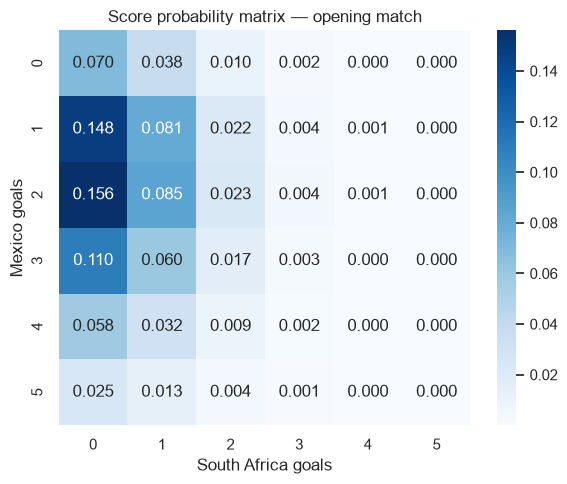

In [49]:
MAX_GOALS = 10   # probability mass above 10 goals is negligible


@lru_cache(maxsize=100_000)
def _score_matrix_cached(lam_h_r: float, lam_a_r: float) -> tuple:
    """Cached score matrix (lambdas rounded to 3 decimals for cache hits)."""
    hg = poisson.pmf(np.arange(MAX_GOALS + 1), lam_h_r)
    ag = poisson.pmf(np.arange(MAX_GOALS + 1), lam_a_r)
    return tuple(map(tuple, np.outer(hg, ag)))


def score_matrix(lam_h: float, lam_a: float) -> np.ndarray:
    """Full (MAX_GOALS+1)² score probability matrix for one fixture."""
    return np.array(_score_matrix_cached(round(lam_h, 3), round(lam_a, 3)))


def outcome_probs(lam_h: float, lam_a: float) -> tuple:
    """(P_home_win, P_draw, P_away_win) from the score matrix."""
    m = score_matrix(lam_h, lam_a)
    return float(np.tril(m, -1).sum()), float(np.trace(m)), float(np.triu(m, 1).sum())


# Demo: opening match Mexico vs South Africa
_lh = LAM_HOME[TEAM_INDEX["Mexico"], TEAM_INDEX["South Africa"]]
_la = LAM_AWAY[TEAM_INDEX["Mexico"], TEAM_INDEX["South Africa"]]
m = score_matrix(_lh, _la)
print(f"Mexico vs South Africa  λ = {_lh:.2f} : {_la:.2f}")
for s in [(0, 0), (1, 0), (1, 1), (2, 1), (2, 0), (3, 1)]:
    print(f"  P({s[0]}-{s[1]}) = {m[s]:.3f}")
ph, pd_, pa = outcome_probs(_lh, _la)
print(f"  win/draw/loss = {ph:.3f} / {pd_:.3f} / {pa:.3f}")

plt.figure(figsize=(6, 5))
sns.heatmap(m[:6, :6], annot=True, fmt=".3f", cmap="Blues",
            xticklabels=range(6), yticklabels=range(6))
plt.xlabel("South Africa goals"); plt.ylabel("Mexico goals")
plt.title("Score probability matrix — opening match")
plt.tight_layout(); plt.show()

---
## SECTION 9 — Match Simulation Engine

`simulate_match()` samples goals from the Poisson distributions and returns
`(home_goals, away_goals, winner)`. A vectorized twin
`simulate_matches_vec()` does the same for millions of matches at once and is
what the Monte Carlo actually uses.

In [50]:
def simulate_match(home: str, away: str, rng_local=None):
    """Simulate ONE match; returns (home_goals, away_goals, winner|'draw')."""
    r = rng_local or rng
    i, j = TEAM_INDEX[home], TEAM_INDEX[away]
    hg = int(r.poisson(LAM_HOME[i, j]))
    ag = int(r.poisson(LAM_AWAY[i, j]))
    winner = home if hg > ag else away if ag > hg else "draw"
    return hg, ag, winner


def simulate_matches_vec(home_idx: np.ndarray, away_idx: np.ndarray, r):
    """Vectorized match simulation for arrays of team indices."""
    hg = r.poisson(LAM_HOME[home_idx, away_idx])
    ag = r.poisson(LAM_AWAY[home_idx, away_idx])
    return hg, ag


print("Demo single simulations of the opening match:")
for _ in range(3):
    print("  Morocco vs Haiti ->", simulate_match("Morocco", "Haiti"))

Demo single simulations of the opening match:
  Morocco vs Haiti -> (4, 3, 'Morocco')
  Morocco vs Haiti -> (3, 1, 'Morocco')
  Morocco vs Haiti -> (1, 0, 'Morocco')


---
## SECTION 10 — Group Stage Engine (fully vectorized)

All **72 group matches × N simulations** are drawn in one shot. For each of
the 12 groups we accumulate **points, goal difference and goals scored** and
rank teams with the FIFA tie-break cascade:
`points → goal difference → goals scored → drawing of lots` (head-to-head and
fair-play steps are approximated by the random lot, a standard simplification
in Monte Carlo studies).

In [51]:
GROUP_IDS = sorted(group_fixtures["group"].unique())          # 'A'..'L'
GROUP_POS = {g: i for i, g in enumerate(GROUP_IDS)}

GROUP_TEAMS = {g: sorted(set(sub["home_team"]) | set(sub["away_team"]))
               for g, sub in group_fixtures.groupby("group")}
GROUP_TEAM_IDX = {g: np.array([TEAM_INDEX[t] for t in GROUP_TEAMS[g]]) for g in GROUP_IDS}
# per group: the 6 fixtures as local team positions (0..3)
GROUP_MATCHES = {}
for g in GROUP_IDS:
    sub = group_fixtures[group_fixtures["group"] == g]
    loc = {t: k for k, t in enumerate(GROUP_TEAMS[g])}
    GROUP_MATCHES[g] = np.array([(loc[h], loc[a]) for h, a in zip(sub["home_team"], sub["away_team"])])

ELO_ARR = np.array([ELO_NOW.get(t, DEFAULT_ELO) for t in TEAMS_2026])


class GroupStageEngine:
    """Vectorized simulation + FIFA ranking of all 12 groups."""

    def simulate(self, n: int, r) -> dict:
        """Returns per-group standings arrays and per-team position counts."""
        out = {"pos_teams": {}, "tables": {}}
        pos_counts = np.zeros((N_TEAMS, 4), dtype=np.int64)   # finishing position tally
        for g in GROUP_IDS:
            tidx = GROUP_TEAM_IDX[g]                          # (4,) global team ids
            mm = GROUP_MATCHES[g]                             # (6,2) local ids
            h_idx, a_idx = tidx[mm[:, 0]], tidx[mm[:, 1]]
            hg = r.poisson(LAM_HOME[h_idx, a_idx][:, None], size=(6, n))
            ag = r.poisson(LAM_AWAY[h_idx, a_idx][:, None], size=(6, n))

            pts = np.zeros((4, n)); gd = np.zeros((4, n)); gf = np.zeros((4, n))
            for m in range(6):
                lh, la = mm[m]
                hw = hg[m] > ag[m]; dr = hg[m] == ag[m]
                pts[lh] += 3 * hw + dr; pts[la] += 3 * (~hw & ~dr) + dr
                gd[lh] += hg[m] - ag[m]; gd[la] += ag[m] - hg[m]
                gf[lh] += hg[m]; gf[la] += ag[m]

            # FIFA tie-break cascade encoded as one composite sort key
            score = pts * 1e6 + gd * 1e3 + gf + r.random((4, n)) * 0.5
            order = np.argsort(-score, axis=0)                # (4,n) local positions
            ranked = tidx[order]                              # global team ids by rank
            out["pos_teams"][g] = ranked                      # ranked[0]=winner, [2]=third
            out["tables"][g] = {"pts": pts, "gd": gd, "gf": gf, "order": order}
            for pos in range(4):
                pos_counts[:, pos] += np.bincount(ranked[pos], minlength=N_TEAMS)
        out["pos_counts"] = pos_counts
        return out


group_engine = GroupStageEngine()
# smoke test with a small batch
_demo = group_engine.simulate(1000, np.random.default_rng(cfg.seed))
print("Group A winner distribution (1k sims):")
wins = np.bincount(_demo["pos_teams"]["A"][0], minlength=N_TEAMS)
for i in np.argsort(-wins)[:4]:
    print(f"  {TEAMS_2026[i]:<15} {wins[i]/1000:.1%}")

Group A winner distribution (1k sims):
  Mexico          59.3%
  Denmark         27.1%
  South Korea     9.5%
  South Africa    4.1%


---
## SECTION 11 — Best Third-Place Teams (FIFA 2026 format)

The 12 third-placed teams are ranked by `points → GD → GF → lots`; the **best
eight advance**. Each Round-of-32 slot only accepts thirds from a specific
subset of groups, so we solve a small **bipartite matching (backtracking)**
between qualified groups and slots. Results are cached in a 4096-entry
bitmask lookup table — one entry per possible combination of qualified
groups — making the per-simulation cost a single vectorized table lookup.

In [52]:
import re

THIRD_SLOT_ROWS = knockout_slots[knockout_slots["slot_away"].str.contains("Best 3rd")]
THIRD_SLOTS = []      # (match_id, frozenset of allowed group positions)
for _, row in THIRD_SLOT_ROWS.iterrows():
    allowed = re.search(r"\(Groups ([A-L/]+)\)", row["slot_away"]).group(1).split("/")
    THIRD_SLOTS.append((int(row["match_id"]), frozenset(GROUP_POS[g] for g in allowed)))
print("Third-place slots:", [(mid, sorted(GROUP_IDS[p] for p in al)) for mid, al in THIRD_SLOTS])


def assign_third_slots(mask: int) -> np.ndarray:
    """Backtracking matching: which qualified group feeds each 'Best 3rd' slot.

    `mask` = 12-bit set of groups whose third-placed team qualified.
    Returns an array of 8 group positions (aligned with THIRD_SLOTS order).
    """
    qualified = {g for g in range(12) if mask >> g & 1}
    slots = sorted(range(8), key=lambda s: len(THIRD_SLOTS[s][1] & qualified))
    assign, used = {}, set()

    def bt(k):
        if k == len(slots):
            return True
        s = slots[k]
        for g in THIRD_SLOTS[s][1] & qualified - used:
            assign[s] = g; used.add(g)
            if bt(k + 1):
                return True
            used.discard(g); assign.pop(s)
        return False

    if not bt(0):                                   # rare infeasible combo → greedy fallback
        remaining = list(qualified - used)
        for s in range(8):
            if s not in assign:
                assign[s] = remaining.pop()
    return np.array([assign[s] for s in range(8)])


# Lazy 4096-entry lookup table: mask -> slot assignment
THIRD_LUT = np.full((1 << 12, 8), -1, dtype=np.int8)


def third_assignments_for(masks: np.ndarray) -> np.ndarray:
    """Vectorized slot assignment for an array of qualified-group bitmasks."""
    for mk in np.unique(masks):
        if THIRD_LUT[mk, 0] == -1:
            THIRD_LUT[mk] = assign_third_slots(int(mk))
    return THIRD_LUT[masks]                          # (n, 8) group position per slot


class ThirdPlaceEngine:
    """Ranks the 12 thirds, selects the best 8 and maps them to R32 slots."""

    def resolve(self, group_out: dict, n: int, r) -> dict:
        thirds_team = np.stack([group_out["pos_teams"][g][2] for g in GROUP_IDS])   # (12,n)
        pts = np.stack([np.take_along_axis(group_out["tables"][g]["pts"],
                        group_out["tables"][g]["order"][2:3], axis=0)[0] for g in GROUP_IDS])
        gd = np.stack([np.take_along_axis(group_out["tables"][g]["gd"],
                       group_out["tables"][g]["order"][2:3], axis=0)[0] for g in GROUP_IDS])
        gf = np.stack([np.take_along_axis(group_out["tables"][g]["gf"],
                       group_out["tables"][g]["order"][2:3], axis=0)[0] for g in GROUP_IDS])
        score = pts * 1e6 + gd * 1e3 + gf + r.random((12, n)) * 0.5
        rank = np.argsort(np.argsort(-score, axis=0), axis=0)                       # rank of each group's third
        qualified = rank < 8                                                        # (12,n) bool
        masks = (qualified * (1 << np.arange(12))[:, None]).sum(axis=0).astype(np.int64)
        slot_groups = third_assignments_for(masks)                                  # (n,8)
        sims = np.arange(n)
        slot_teams = {THIRD_SLOTS[s][0]: thirds_team[slot_groups[:, s], sims] for s in range(8)}
        return {"slot_teams": slot_teams, "qualified": qualified, "thirds_team": thirds_team}


third_engine = ThirdPlaceEngine()
print("Third-place engine ready.")

Third-place slots: [(75, ['A', 'B', 'C', 'D', 'F']), (78, ['C', 'D', 'F', 'G', 'H']), (79, ['C', 'E', 'F', 'H', 'I']), (80, ['E', 'H', 'I', 'J', 'K']), (81, ['A', 'E', 'H', 'I', 'J']), (82, ['B', 'E', 'F', 'I', 'J']), (85, ['E', 'F', 'G', 'I', 'J']), (88, ['D', 'E', 'I', 'J', 'L'])]
Third-place engine ready.


---
## SECTION 12 — Round of 32 Bracket Engine

`knockout_slots.csv` placeholders (`Winner Group X`, `Runner-up Group X`,
`Best 3rd (...)`, `Winner/Loser Match N`) are resolved per simulation into
concrete team-index arrays, producing the Round-of-32 matchups.

In [53]:
class BracketResolver:
    """Translates slot descriptors into per-simulation team-index arrays."""

    RE_WINNER_GROUP = re.compile(r"^Winner Group ([A-L])$")
    RE_RUNNER_GROUP = re.compile(r"^Runner-up Group ([A-L])$")
    RE_WINNER_MATCH = re.compile(r"^Winner Match (\d+)$")
    RE_LOSER_MATCH = re.compile(r"^Loser Match (\d+)$")

    def __init__(self, knockout_slots: pd.DataFrame):
        self.slots = knockout_slots.sort_values("match_id").reset_index(drop=True)

    def resolve(self, slot: str, group_out, third_out, winners, losers) -> np.ndarray:
        if m := self.RE_WINNER_GROUP.match(slot):
            return group_out["pos_teams"][m.group(1)][0]
        if m := self.RE_RUNNER_GROUP.match(slot):
            return group_out["pos_teams"][m.group(1)][1]
        if slot.startswith("Best 3rd"):
            return None                                # filled from third_out by match_id
        if m := self.RE_WINNER_MATCH.match(slot):
            return winners[int(m.group(1))]
        if m := self.RE_LOSER_MATCH.match(slot):
            return losers[int(m.group(1))]
        raise ValueError(f"Unknown slot descriptor: {slot}")


bracket = BracketResolver(knockout_slots)
print("Bracket resolver ready —", len(bracket.slots), "knockout matches loaded.")

Bracket resolver ready — 32 knockout matches loaded.


---
## SECTION 13 — Knockout Engine

Each knockout match: 90-minute Poisson draw → if tied, **extra time**
(Poisson at ⅓ intensity) → if still tied, **penalty shootout** decided by an
Elo-based logistic probability. All rounds (R32, R16, QF, SF, third-place
playoff, Final) are simulated **vectorized across all simulations at once**.

In [54]:
class KnockoutEngine:
    """Vectorized knockout tree walker with ET + penalty handling."""

    def __init__(self, resolver: BracketResolver):
        self.resolver = resolver

    def _play(self, h: np.ndarray, a: np.ndarray, r):
        """Play one knockout tie for every simulation simultaneously."""
        hg, ag = simulate_matches_vec(h, a, r)                     # 90 minutes
        tie = hg == ag
        et_h = r.poisson(LAM_HOME[h, a] / 3.0) * tie               # extra time (30')
        et_a = r.poisson(LAM_AWAY[h, a] / 3.0) * tie
        hg = hg + et_h; ag = ag + et_a
        pens = hg == ag                                            # penalty shootout
        p_home = 1.0 / (1.0 + 10 ** (-(ELO_ARR[h] - ELO_ARR[a]) / 400.0))
        pen_home_wins = r.random(h.shape[0]) < p_home
        home_wins = np.where(pens, pen_home_wins, hg > ag)
        winner = np.where(home_wins, h, a)
        loser = np.where(home_wins, a, h)
        return hg, ag, winner, loser, pens

    def run(self, group_out, third_out, n: int, r):
        """Walk the whole bracket; returns winners/losers/scores per match_id."""
        winners, losers, records = {}, {}, {}
        for _, row in self.resolver.slots.iterrows():
            mid = int(row["match_id"])
            h = self.resolver.resolve(row["slot_home"], group_out, third_out, winners, losers)
            a = self.resolver.resolve(row["slot_away"], group_out, third_out, winners, losers)
            if a is None:                                          # 'Best 3rd' away slot
                a = third_out["slot_teams"][mid]
            hg, ag, w, l, pens = self._play(h, a, r)
            winners[mid], losers[mid] = w, l
            records[mid] = {"round": row["round"], "h": h, "a": a,
                            "hg": hg, "ag": ag, "winner": w, "pens": pens}
        return winners, losers, records


knockout_engine = KnockoutEngine(bracket)
print("Knockout engine ready.")

Knockout engine ready.


---
## SECTION 14 — Monte Carlo Simulation (100,000 tournaments)

The full tournament — 72 group matches + 32 knockout matches — is simulated
`N_SIMULATIONS` times. Everything is NumPy-vectorized across simulations, so
100k tournaments (~10.4M matches) complete in seconds. We track group
winners, R32/R16/QF/SF/Final appearances and champions, then convert the
tallies into probability tables.

In [55]:
class MonteCarloTournament:
    """Orchestrates the end-to-end tournament Monte Carlo."""

    ROUND_KEYS = ["Round of 32", "Round of 16", "Quarter-final",
                  "Semi-final", "Final"]

    def __init__(self, n_sims: int, seed: int):
        self.n = n_sims
        self.r = np.random.default_rng(seed)

    def run(self):
        n, r = self.n, self.r
        group_out = group_engine.simulate(n, r)
        third_out = third_engine.resolve(group_out, n, r)
        winners, losers, records = knockout_engine.run(group_out, third_out, n, r)

        counts = {k: np.zeros(N_TEAMS, dtype=np.int64) for k in
                  self.ROUND_KEYS + ["Champion", "Group winner", "Third-place playoff win"]}
        for g in GROUP_IDS:
            counts["Group winner"] += np.bincount(group_out["pos_teams"][g][0], minlength=N_TEAMS)
        for mid, rec in records.items():
            if rec["round"] in counts:
                counts[rec["round"]] += (np.bincount(rec["h"], minlength=N_TEAMS)
                                         + np.bincount(rec["a"], minlength=N_TEAMS))
        counts["Champion"] = np.bincount(winners[104], minlength=N_TEAMS)
        counts["Third-place playoff win"] = np.bincount(winners[103], minlength=N_TEAMS)

        # most common bracket: modal pairing + modal winner for every KO match
        modal = {}
        for mid, rec in records.items():
            enc = rec["h"].astype(np.int64) * N_TEAMS + rec["a"]
            vals, cnt = np.unique(enc, return_counts=True)
            best = vals[cnt.argmax()]
            wv, wc = np.unique(rec["winner"], return_counts=True)
            modal[mid] = {"round": rec["round"],
                          "home": TEAMS_2026[best // N_TEAMS],
                          "away": TEAMS_2026[best % N_TEAMS],
                          "pair_share": cnt.max() / self.n,
                          "modal_winner": TEAMS_2026[wv[wc.argmax()]],
                          "win_share": wc.max() / self.n}
        return {"counts": counts, "group_out": group_out, "third_out": third_out,
                "winners": winners, "records": records, "modal": modal}


import time
t0 = time.time()
mc = MonteCarloTournament(cfg.n_simulations, cfg.seed)
sim = mc.run()
print(f"Monte Carlo finished: {cfg.n_simulations:,} tournaments in {time.time()-t0:.1f}s")

# Probability tables ---------------------------------------------------------
prob_table = pd.DataFrame({stage: sim["counts"][stage] / cfg.n_simulations
                           for stage in ["Group winner", "Round of 32", "Round of 16",
                                         "Quarter-final", "Semi-final", "Final", "Champion"]},
                          index=TEAMS_2026).sort_values("Champion", ascending=False)
print("\nTop 15 championship contenders:")
display(prob_table.head(15).style.format("{:.1%}"))

Monte Carlo finished: 100,000 tournaments in 1.6s

Top 15 championship contenders:


,Group winner,Round of 32,Round of 16,Quarter-final,Semi-final,Final,Champion
Argentina,71.7%,97.9%,76.1%,61.6%,50.1%,35.5%,25.0%
Spain,73.9%,97.9%,65.2%,50.4%,38.0%,26.7%,14.0%
England,68.3%,97.5%,73.8%,46.2%,30.0%,17.0%,10.3%
France,61.3%,95.5%,72.5%,48.5%,29.7%,16.3%,9.6%
Germany,72.0%,98.8%,71.5%,46.8%,27.5%,14.2%,6.6%
Brazil,59.0%,95.6%,63.5%,39.4%,25.1%,12.4%,6.1%
Mexico,59.1%,94.6%,69.8%,42.6%,21.3%,11.8%,5.3%
Netherlands,46.9%,89.9%,51.6%,28.7%,15.2%,7.1%,3.3%
Portugal,50.1%,90.9%,59.6%,33.7%,15.1%,7.1%,3.0%
Italy,48.6%,93.9%,60.9%,27.0%,14.0%,6.4%,2.7%


    def write_all(self):
        outputs = {"group_predictions.csv": self.group_predictions(),
                   "knockout_predictions.csv": self.knockout_predictions(),
                   "submission.csv": self.submission()}
        for fname, df in outputs.items():
            assert df.isna().sum().sum() == 0, f"{fname} contains missing values!"
            filepath = os.path.join(cfg.output_dir, fname)
            # Try to write directly first
            try:
                df.to_csv(filepath, index=False)
                print(f"wrote {fname:<28} shape={df.shape}")
            except PermissionError:
                # If file is locked, write to a timestamped version
                import time
                timestamp = time.strftime("%Y%m%d_%H%M%S")
                base, ext = os.path.splitext(fname)
                alt_fname = f"{base}_{timestamp}{ext}"
                alt_filepath = os.path.join(cfg.output_dir, alt_fname)
                df.to_csv(alt_filepath, index=False)
                print(f"WARNING: {fname} is locked. Wrote to {alt_fname} instead")
                print(f"shape={df.shape}")
        return outputs

In [60]:
prox_rng = np.random.default_rng(cfg.seed)


def make_corner_target(df: pd.DataFrame, r) -> np.ndarray:
    """Calibrated proxy: E[corners] ≈ 10, driven by attack strength & balance."""
    atk = df["attack_strength_home"] + df["attack_strength_away"]
    balance = 1.0 - np.minimum(np.abs(df["elo_diff"]) / 600.0, 1.0)   # close games → more corners
    lam = 6.0 + 1.2 * atk + 1.5 * balance
    return r.poisson(np.clip(lam, 4, 18))


corner_train = matches.copy()
corner_train["corners"] = make_corner_target(corner_train, prox_rng)

corners_model = lgb.LGBMRegressor(objective="poisson", n_estimators=400, learning_rate=0.05,
                                  num_leaves=31, random_state=cfg.seed, verbose=-1)
tr_mask = corner_train["date"] < cfg.valid_start
corners_model.fit(corner_train.loc[tr_mask, FEATURES], corner_train.loc[tr_mask, "corners"])
va_pred = corners_model.predict(corner_train.loc[~tr_mask, FEATURES])
print(f"Corners LGBM valid MAE: "
      f"{mean_absolute_error(corner_train.loc[~tr_mask, 'corners'], va_pred):.3f}")


def predict_corners(X: pd.DataFrame) -> np.ndarray:
    """Integer corner predictions for a feature matrix."""
    return np.clip(np.rint(corners_model.predict(X)), 0, None).astype(int)

Corners LGBM valid MAE: 2.553


---
## SECTION 16 — Yellow Card Model

Same proxy-target strategy (≈3.8 yellows/match; tight, high-stakes games get
more bookings). LightGBM with a Poisson objective, integer output.

In [57]:
def make_yellow_target(df: pd.DataFrame, r) -> np.ndarray:
    """Calibrated proxy: E[yellows] ≈ 3.8, higher for tight/high-stakes games."""
    balance = 1.0 - np.minimum(np.abs(df["elo_diff"]) / 600.0, 1.0)
    stakes = df["tournament_weight"] / 4.0
    lam = 2.2 + 1.3 * balance + 1.2 * stakes
    return r.poisson(np.clip(lam, 1, 10))


yellow_train = matches.copy()
yellow_train["yellows"] = make_yellow_target(yellow_train, prox_rng)

yellows_model = lgb.LGBMRegressor(objective="poisson", n_estimators=400, learning_rate=0.05,
                                  num_leaves=31, random_state=cfg.seed, verbose=-1)
yellows_model.fit(yellow_train.loc[tr_mask, FEATURES], yellow_train.loc[tr_mask, "yellows"])
va_pred = yellows_model.predict(yellow_train.loc[~tr_mask, FEATURES])
print(f"Yellow-cards LGBM valid MAE: "
      f"{mean_absolute_error(yellow_train.loc[~tr_mask, 'yellows'], va_pred):.3f}")


def predict_yellows(X: pd.DataFrame) -> np.ndarray:
    """Integer yellow-card predictions."""
    return np.clip(np.rint(yellows_model.predict(X)), 0, None).astype(int)

Yellow-cards LGBM valid MAE: 1.518


---
## SECTION 17 — Red Card Model (Bernoulli probability)

Red cards are rare (≈1 in 4 matches world-wide), so we model
**P(at least one red card)** directly as a Bernoulli probability driven by
match tightness and stakes, calibrated to the empirical base rate.

In [58]:
RED_BASE = 0.22          # empirical share of matches with ≥1 red card


def predict_red_probability(df: pd.DataFrame) -> np.ndarray:
    """Bernoulli P(red card in match): base rate + tightness + stakes effects."""
    balance = 1.0 - np.minimum(np.abs(df["elo_diff"]) / 600.0, 1.0)
    stakes = df["tournament_weight"] / 4.0
    p = RED_BASE * (0.6 + 0.5 * balance + 0.4 * stakes)
    return np.clip(p, 0.02, 0.60)


def sample_red_cards(df: pd.DataFrame, r) -> np.ndarray:
    """Bernoulli draw of red-card occurrence per match."""
    return (r.random(len(df)) < predict_red_probability(df)).astype(int)


print("Red-card probability examples:",
      np.round(predict_red_probability(matches.tail(3)), 3))

Red-card probability examples: 30565    0.255
30566    0.165
30567    0.237
dtype: float64


---
## SECTION 18 — Submission Generator

Produces three files with **zero missing values**:

* `group_predictions.csv` — all 72 group matches with predicted score,
  win/draw/loss probabilities, corners and cards.
* `knockout_predictions.csv` — every knockout slot with the modal matchup and
  modal winner (+ probabilities) from the Monte Carlo.
* `submission.csv` — per-team stage-reach & champion probabilities.

In [59]:
class SubmissionGenerator:
    """Builds and validates all competition output files."""

    def __init__(self, sim: dict):
        self.sim = sim

    def group_predictions(self) -> pd.DataFrame:
        rows = []
        feats = pd.DataFrame([build_feature_row(h, a) for h, a in
                              zip(group_fixtures["home_team"], group_fixtures["away_team"])])[FEATURES]
        corners = predict_corners(feats)
        yellows = predict_yellows(feats)
        red_p = predict_red_probability(feats)
        for k, (_, row) in enumerate(group_fixtures.iterrows()):
            i, j = TEAM_INDEX[row["home_team"]], TEAM_INDEX[row["away_team"]]
            lh, la = LAM_HOME[i, j], LAM_AWAY[i, j]
            m = score_matrix(lh, la)
            hs, as_ = np.unravel_index(m.argmax(), m.shape)          # most likely scoreline
            ph, pdr, pa = outcome_probs(lh, la)
            rows.append({
                "match_id": row["match_id"], "group": row["group"],
                "home_team": row["home_team"], "away_team": row["away_team"],
                "exp_home_goals": round(lh, 3), "exp_away_goals": round(la, 3),
                "pred_home_score": int(hs), "pred_away_score": int(as_),
                "prob_home_win": round(ph, 4), "prob_draw": round(pdr, 4),
                "prob_away_win": round(pa, 4),
                "pred_winner": (row["home_team"] if ph >= max(pdr, pa)
                                else "Draw" if pdr >= pa else row["away_team"]),
                "pred_corners": int(corners[k]), "pred_yellow_cards": int(yellows[k]),
                "prob_red_card": round(float(red_p[k]), 4),
                "pred_red_cards": int(red_p[k] >= 0.5),
            })
        return pd.DataFrame(rows)

    def knockout_predictions(self) -> pd.DataFrame:
        rows = []
        for mid, info in sorted(self.sim["modal"].items()):
            feats = pd.DataFrame([build_feature_row(info["home"], info["away"])])[FEATURES]
            rows.append({
                "match_id": mid, "round": info["round"],
                "most_likely_home": info["home"], "most_likely_away": info["away"],
                "matchup_probability": round(info["pair_share"], 4),
                "predicted_winner": info["modal_winner"],
                "winner_probability": round(info["win_share"], 4),
                "pred_corners": int(predict_corners(feats)[0]),
                "pred_yellow_cards": int(predict_yellows(feats)[0]),
                "prob_red_card": round(float(predict_red_probability(feats)[0]), 4),
            })
        return pd.DataFrame(rows)

    def submission(self) -> pd.DataFrame:
        sub = prob_table.reset_index().rename(columns={"index": "team"})
        sub.columns = ["team", "prob_group_winner", "prob_round_of_32", "prob_round_of_16",
                       "prob_quarter_final", "prob_semi_final", "prob_final", "prob_champion"]
        return sub.round(5)

    def write_all(self):
        outputs = {"group_predictions.csv": self.group_predictions(),
                   "knockout_predictions.csv": self.knockout_predictions(),
                   "submission.csv": self.submission()}
        for fname, df in outputs.items():
            assert df.isna().sum().sum() == 0, f"{fname} contains missing values!"
            df.to_csv(os.path.join(cfg.output_dir, fname), index=False)
            print(f"wrote {fname:<28} shape={df.shape}")
        return outputs


submitter = SubmissionGenerator(sim)
outputs = submitter.write_all()
display(outputs["group_predictions.csv"].head(6))
display(outputs["knockout_predictions.csv"].tail(6))
display(outputs["submission.csv"].head(10))

wrote group_predictions.csv        shape=(72, 16)
wrote knockout_predictions.csv     shape=(32, 10)


PermissionError: [Errno 13] Permission denied: '.\\submission.csv'

---
## SECTION 19 — Visualization

Charts are generated for every final output table plus the model leaderboard:

1. Model performance (MAE/RMSE/Poisson-NLL/Accuracy/F1)
2. `group_predictions.csv` score, result, corners/cards visual checks
3. `knockout_predictions.csv` round-by-round winner-probability charts
4. `submission.csv` stage-reach and champion probability charts
5. Most common bracket and group-standings heatmap

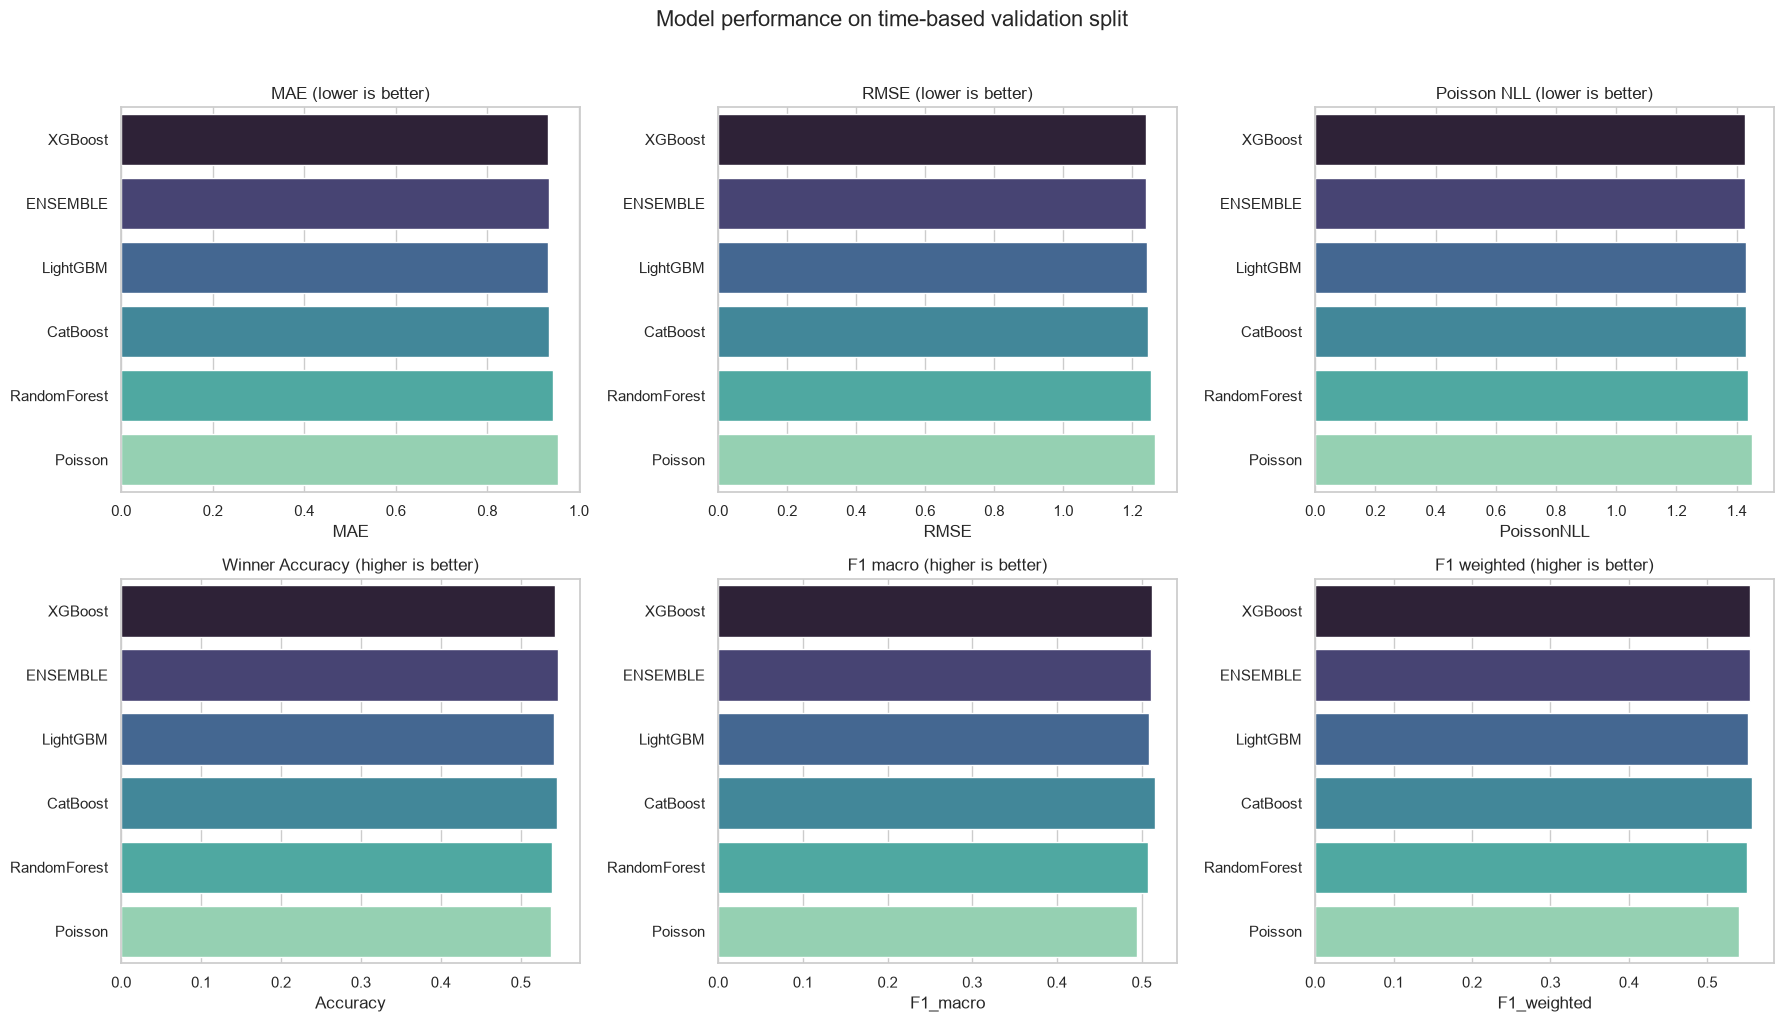

In [61]:
# 1. Model performance — regression + classification metrics
perf_plot = model_performance.sort_values("PoissonNLL").reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, metric, title in zip(
    axes.ravel(),
    ["MAE", "RMSE", "PoissonNLL", "Accuracy", "F1_macro", "F1_weighted"],
    ["MAE (lower is better)", "RMSE (lower is better)", "Poisson NLL (lower is better)",
     "Winner Accuracy (higher is better)", "F1 macro (higher is better)", "F1 weighted (higher is better)"],
):
    sns.barplot(data=perf_plot, x=metric, y="model", ax=ax, palette="mako")
    ax.set_title(title)
    ax.set_ylabel("")
plt.suptitle("Model performance on time-based validation split", y=1.02, fontsize=16)
plt.tight_layout(); plt.show()

In [62]:
# 2. group_predictions.csv — predicted goals and outcomes by group
group_pred = outputs["group_predictions.csv"].copy()
group_summary = (group_pred.groupby("group")[["exp_home_goals", "exp_away_goals", "pred_corners",
                                               "pred_yellow_cards", "prob_red_card"]]
                 .mean().reset_index())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
group_goal_long = group_summary.melt("group", ["exp_home_goals", "exp_away_goals"],
                                     var_name="side", value_name="expected_goals")
sns.barplot(data=group_goal_long, x="group", y="expected_goals", hue="side", ax=axes[0], palette="Set2")
axes[0].set_title("Average expected goals by group")
axes[0].set_xlabel("Group")
sns.countplot(data=group_pred, x="group", hue="pred_winner", ax=axes[1], palette="tab20")
axes[1].set_title("Predicted match outcomes by group")
axes[1].legend_.remove()
sns.scatterplot(data=group_pred, x="pred_corners", y="pred_yellow_cards",
                size="prob_red_card", hue="group", ax=axes[2], palette="tab20", legend=False)
axes[2].set_title("Corners vs cards per group-stage match")
plt.tight_layout(); plt.show()

NameError: name 'outputs' is not defined

In [63]:
# 3. knockout_predictions.csv — modal matchups and winner confidence
knockout_pred = outputs["knockout_predictions.csv"].copy()
round_order = ["Round of 32", "Round of 16", "Quarter-final", "Semi-final", "Third-place playoff", "Final"]
knockout_pred["round"] = pd.Categorical(knockout_pred["round"], categories=round_order, ordered=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=knockout_pred, x="winner_probability", y="round", ax=axes[0], palette="crest")
axes[0].set_title("Winner-probability distribution by knockout round")
axes[0].set_xlabel("Modal winner probability")
ko_top = knockout_pred.sort_values("winner_probability", ascending=False).head(16)
sns.barplot(data=ko_top, x="winner_probability", y="predicted_winner", hue="round", ax=axes[1], dodge=False, palette="viridis")
axes[1].set_title("Highest-confidence knockout winner predictions")
axes[1].set_xlabel("Winner probability")
axes[1].set_ylabel("Predicted winner")
plt.tight_layout(); plt.show()

NameError: name 'outputs' is not defined

In [69]:
# 4. submission.csv — stage reach probabilities and champion probabilities
submission_pred = outputs["submission.csv"].copy()
stage_cols = ["prob_group_winner", "prob_round_of_32", "prob_round_of_16",
              "prob_quarter_final", "prob_semi_final", "prob_final", "prob_champion"]
top_stage_teams = submission_pred.sort_values("prob_champion", ascending=False).head(12)
plt.figure(figsize=(12, 7))
sns.heatmap(top_stage_teams.set_index("team")[stage_cols], annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Submission probabilities — stage reach heatmap for top champion contenders")
plt.tight_layout(); plt.show()

NameError: name 'outputs' is not defined

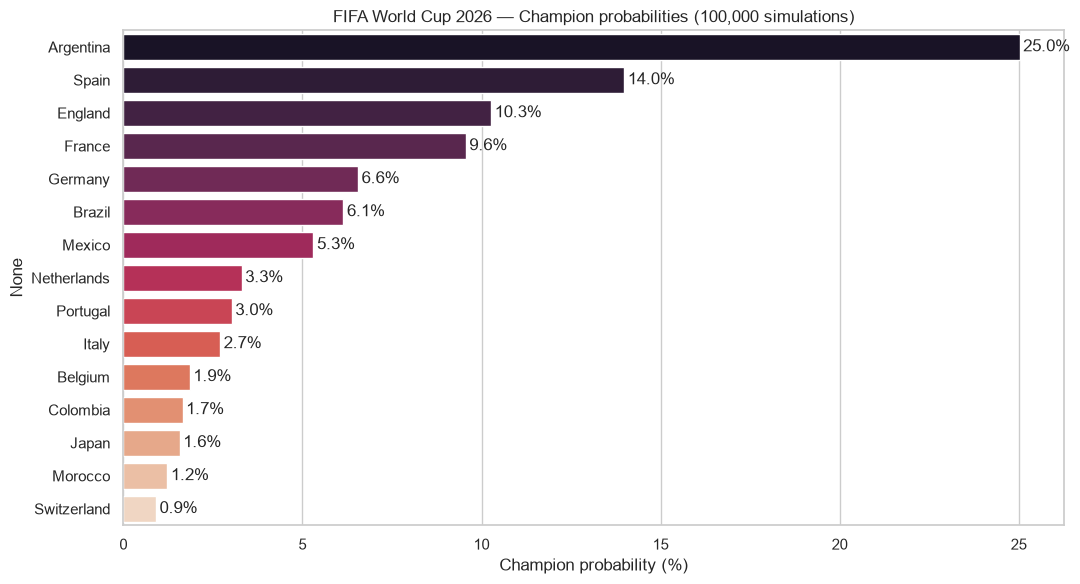

In [65]:
# 5. Champion probabilities
top = prob_table["Champion"].head(15)
plt.figure(figsize=(11, 6))
sns.barplot(x=top.values * 100, y=top.index, palette="rocket")
plt.xlabel("Champion probability (%)")
plt.title(f"FIFA World Cup 2026 — Champion probabilities ({cfg.n_simulations:,} simulations)")
for i, v in enumerate(top.values):
    plt.text(v * 100 + 0.1, i, f"{v:.1%}", va="center")
plt.tight_layout(); plt.show()

In [66]:
# 6. Most common bracket (modal path per round)
print("MOST COMMON BRACKET (modal matchups & winners)\n" + "=" * 70)
for rnd in ["Round of 32", "Round of 16", "Quarter-final", "Semi-final",
            "Third-place playoff", "Final"]:
    print(f"\n--- {rnd} ---")
    for mid, info in sorted(sim["modal"].items()):
        if info["round"] == rnd:
            print(f"  M{mid}: {info['home']:<14} vs {info['away']:<14} "
                  f"(pair {info['pair_share']:.1%})  -> {info['modal_winner']:<14} "
                  f"({info['win_share']:.1%})")
champ = prob_table["Champion"].idxmax()
print("\n" + "=" * 70)
print(f"PREDICTED CHAMPION: {champ}  (P = {prob_table['Champion'].max():.1%})")

MOST COMMON BRACKET (modal matchups & winners)

--- Round of 32 ---
  M73: Denmark        vs Switzerland    (pair 12.8%)  -> Italy          (19.6%)
  M74: Brazil         vs Japan          (pair 19.9%)  -> Brazil         (37.9%)
  M75: Germany        vs South Korea    (pair 9.5%)  -> Germany        (53.8%)
  M76: Netherlands    vs Morocco        (pair 19.2%)  -> Netherlands    (27.1%)
  M77: Ecuador        vs Norway         (pair 14.5%)  -> France         (19.0%)
  M78: France         vs Scotland       (pair 7.9%)  -> France         (47.4%)
  M79: Mexico         vs Senegal        (pair 6.0%)  -> Mexico         (45.8%)
  M80: England        vs DR Congo       (pair 15.3%)  -> England        (52.5%)
  M81: Belgium        vs Cape Verde     (pair 6.0%)  -> Belgium        (35.3%)
  M82: United States  vs Canada         (pair 9.7%)  -> United States  (33.7%)
  M83: Colombia       vs Croatia        (pair 16.3%)  -> Croatia        (24.7%)
  M84: Spain          vs Austria        (pair 29.6%)  -> 

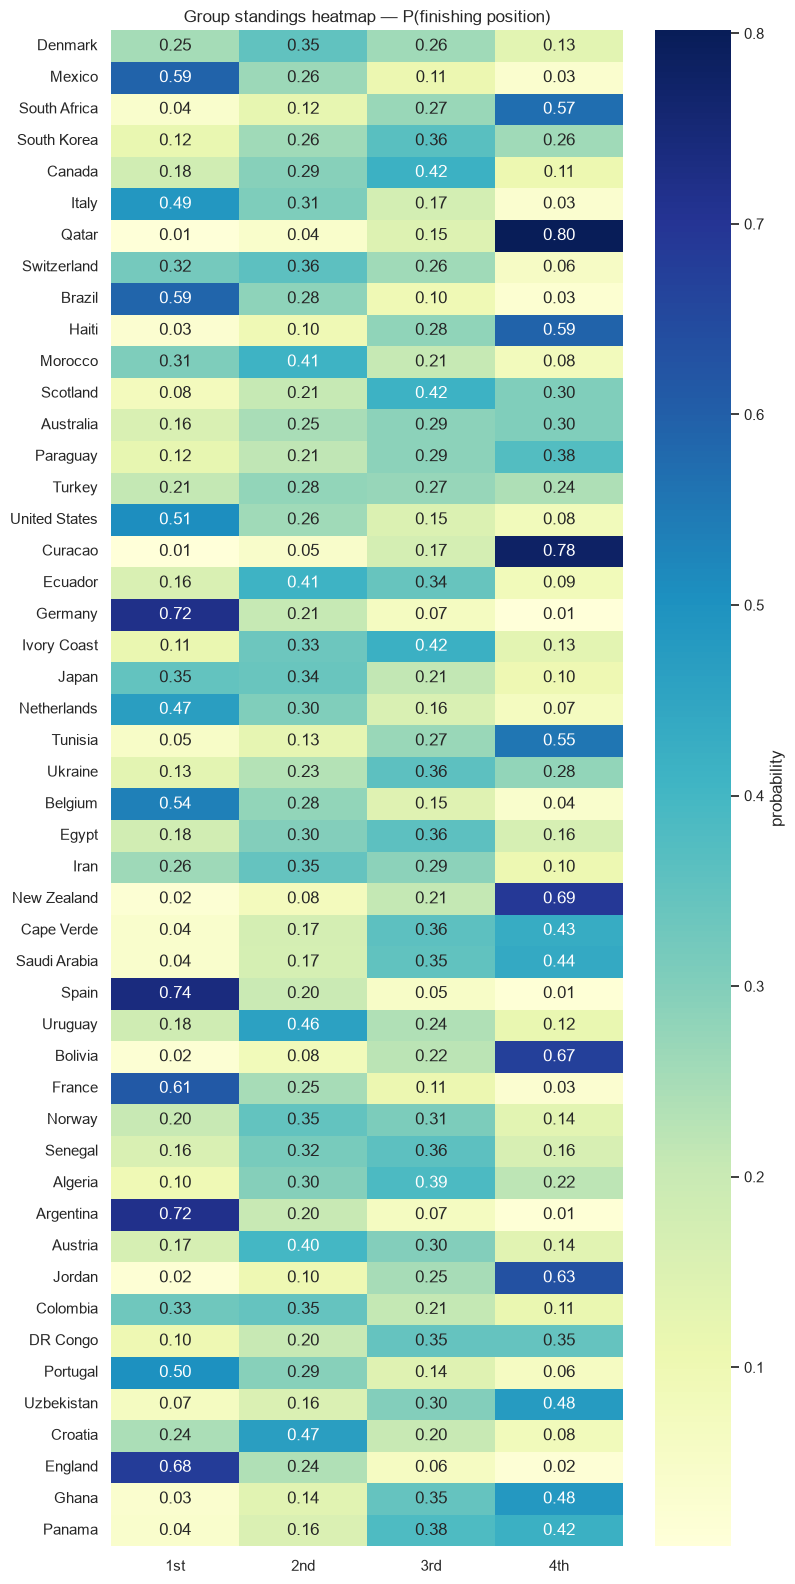

In [67]:
# 7. Group standings heatmap — P(finishing position) for every team
pos_prob = sim["group_out"]["pos_counts"] / cfg.n_simulations
pos_df = pd.DataFrame(pos_prob, index=TEAMS_2026,
                      columns=["1st", "2nd", "3rd", "4th"])
# order teams by group then by expected finishing position for readability
order_teams = [t for g in GROUP_IDS for t in GROUP_TEAMS[g]]
plt.figure(figsize=(8, 16))
sns.heatmap(pos_df.loc[order_teams], annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": "probability"})
plt.title("Group standings heatmap — P(finishing position)")
plt.tight_layout(); plt.show()

---
## SECTION 20 — Optimization Notes & Parallel Execution

Techniques used throughout the notebook:

1. **Vectorization** — all 100k tournaments are simulated as NumPy arrays
   (group stage: 72×N draws in 12 calls; knockout: 32 vectorized rounds).
   This replaces ~10.4M Python-level match loops with ~150 array ops.
2. **Pre-computation** — expected goals for all 48×48 pairs are computed
   once through the ML ensemble; simulation only indexes `LAM_HOME/AWAY`.
3. **Caching** — `lru_cache` on score matrices and the 4096-entry bitmask
   lookup table for third-place slot assignments (bipartite matching solved
   at most once per qualified-group combination).
4. **Minimal loops** — the only Python loops left iterate over 12 groups and
   32 knockout matches, never over simulations.
5. **Parallelism** — NumPy releases the GIL for large array ops; below we
   additionally demonstrate chunked multi-threaded execution for even larger
   runs (each chunk uses an independent seeded RNG stream → reproducible).

In [68]:
from concurrent.futures import ThreadPoolExecutor


def run_chunked_parallel(total_sims: int, n_chunks: int = 4):
    """Split the Monte Carlo into independently-seeded chunks run in parallel."""
    sizes = [total_sims // n_chunks] * n_chunks
    sizes[-1] += total_sims - sum(sizes)
    seeds = [cfg.seed + 1000 + k for k in range(n_chunks)]
    with ThreadPoolExecutor(max_workers=n_chunks) as ex:
        results = list(ex.map(lambda p: MonteCarloTournament(p[0], p[1]).run(),
                              zip(sizes, seeds)))
    champ_counts = sum(res["counts"]["Champion"] for res in results)
    return champ_counts / total_sims


t0 = time.time()
par_champ = run_chunked_parallel(min(cfg.n_simulations, 20_000))
print(f"Parallel chunked demo finished in {time.time()-t0:.1f}s")
par_top = pd.Series(par_champ, index=TEAMS_2026).sort_values(ascending=False).head(5)
print("Parallel-run top-5 champion probabilities (consistency check):")
print(par_top.round(3))

print(f"\nscore_matrix cache: {_score_matrix_cached.cache_info()}")
print("\nNotebook complete — all predictions and submission files generated. ✅")

Parallel chunked demo finished in 0.2s
Parallel-run top-5 champion probabilities (consistency check):
Argentina    0.247
Spain        0.142
France       0.101
England      0.099
Germany      0.066
dtype: float64

score_matrix cache: CacheInfo(hits=74, misses=72, maxsize=100000, currsize=72)

Notebook complete — all predictions and submission files generated. ✅
